In [1]:
import matplotlib.pyplot as plt
import pandas as pd

## Plot results

In [ ]:
results = pd.read_csv('./../data/listening_test_result.csv')

In [3]:
def group_music_training(results, condition):

    # remove rows with condition
    results = results[condition]

    # order results by musical_training_years
    results = results.sort_values(by=['musical_training_years'])

    score_per_participant = results.groupby(['session_uuid', 'method', 'musical_training_years'])['rating_score'].mean().reset_index()

    # discard session uuid with rating_score for reference is lower than that of random
    invalid_session_uuids = score_per_participant.groupby('session_uuid').filter(lambda x: ((x.loc[x['method'] == 'Ref', 'rating_score'].values[0] * 0.95 <= x.loc[x['method'] == 'Random', 'rating_score'].values[0]) and (x.loc[x['method'] == 'Ref', 'rating_score'].values[0] * 1.05 >= x.loc[x['method'] == 'Random', 'rating_score'].values[0])))['session_uuid'].unique()
    score_per_participant = score_per_participant[~score_per_participant['session_uuid'].isin(invalid_session_uuids)]

    # group by trial_id, rating_stimulus, method and calculate mean rating_score across participants
    results_score_averaged = score_per_participant.groupby(['method'])['rating_score'].mean().reset_index()

    return score_per_participant, results_score_averaged

In [4]:
condition_less3 = (results['musical_training_years'] < 3)
score_per_participant_less3, results_score_averaged_less3 = group_music_training(results=results, condition=condition_less3)

condition_3to10 = (results['musical_training_years'] >= 3) & (results['musical_training_years'] <= 10)
score_per_participant_3to10, results_score_averaged_3to10 = group_music_training(results=results, condition=condition_3to10)

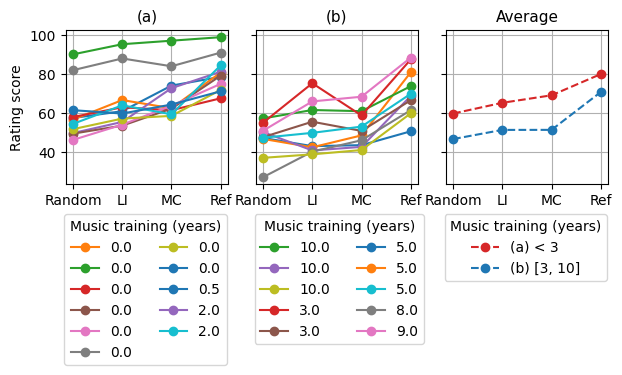

In [ ]:
# plot rating_score vs methods, each session_uuid is a line, following the order ["Ran", "Len", "Cal", "Ref"]
# "instrument" as legend
fig, axs = plt.subplots(figsize=(7, 2), nrows=1, ncols=3, sharex=False, sharey=True)
ordered_methods = ["Random", "LI", "MC", "Ref"]

#################### score per participant < 3
# density of legend color by musical training years
for session_uuid, group in score_per_participant_less3.groupby('session_uuid'):
    group = group.set_index('method').reindex(ordered_methods).reset_index()
    axs[0].plot(group['method'], group['rating_score'], marker='o', label=f"{group['musical_training_years'].iloc[0]}")
axs[0].set_ylabel('Rating score')
axs[0].set_title('(a)', fontsize=11)
# order legend by music training (years), the same training years the same color
handles, labels = axs[0].get_legend_handles_labels()
labels, handles = zip(*sorted(zip(labels, handles), key=lambda x: x[0]))
axs[0].legend(handles, labels, title='Music training (years)', bbox_to_anchor=(-0.05, -0.15), ncol=2, loc='upper left')
axs[0].grid()


#################### score per participant 3 to 10
for session_uuid, group in score_per_participant_3to10.groupby('session_uuid'):
    group = group.set_index('method').reindex(ordered_methods).reset_index()
    axs[1].plot(group['method'], group['rating_score'], marker='o', label=f"{group['musical_training_years'].iloc[0]}")
axs[1].set_title('(b)', fontsize=11)
# order legend by music training (years), the same training years the same color
handles, labels = axs[1].get_legend_handles_labels()
labels, handles = zip(*sorted(zip(labels, handles), key=lambda x: x[0]))
axs[1].legend(handles, labels, title='Music training (years)', bbox_to_anchor=(-0.05, -0.15), ncol=2, loc='upper left')
axs[1].grid()


#################### all averaged rank
# line plot score_across_participants['method'], score_across_participants['rating_score']
results_score_averaged_less3 = results_score_averaged_less3.set_index('method').reindex(ordered_methods).reset_index()
results_score_averaged_3to10 = results_score_averaged_3to10.set_index('method').reindex(ordered_methods).reset_index()
axs[2].plot(results_score_averaged_less3['method'], results_score_averaged_less3['rating_score'], marker='o', color='tab:red', linestyle='--', label='(a) < 3')
axs[2].plot(results_score_averaged_3to10['method'], results_score_averaged_3to10['rating_score'], marker='o', color='tab:blue', linestyle='--', label='(b) [3, 10]')
axs[2].legend(title='Music training (years)', bbox_to_anchor=(-0.05, -0.15), loc='upper left')
axs[2].set_title('Average', fontsize=11)
axs[2].grid()

plt.subplots_adjust(wspace=0.17)  # space between subplots

plt.savefig('../outputs/listening_test_results.pdf', bbox_inches='tight')

## Satistics

In [ ]:
import statsmodels.formula.api as smf
import pingouin as pg

In [7]:
cols_to_remove = ["difficulty", "rating_time", "rating_comment", "rating_stimulus", "type_of_training", "session_test_id"]
results = results.drop(columns=cols_to_remove)
results = results.rename(columns={"session_uuid": "participant_id"})
results = results.rename(columns={"trial_id": "track_id"})

In [8]:
results = results[results['musical_training_years'] <= 10]
score_per_participant = results.groupby(['participant_id', 'method', 'musical_training_years'])['rating_score'].mean().reset_index()
invalid_participant_uuids = score_per_participant.groupby('participant_id').filter(lambda x: ((x.loc[x['method'] == 'Ref', 'rating_score'].values[0] * 0.95 <= x.loc[x['method'] == 'Random', 'rating_score'].values[0]) and (x.loc[x['method'] == 'Ref', 'rating_score'].values[0] * 1.05 >= x.loc[x['method'] == 'Random', 'rating_score'].values[0])))['participant_id'].unique()
# order results by musical_training_years
invalid_participant_uuids = set(invalid_participant_uuids)
results = results[~results['participant_id'].isin(invalid_participant_uuids)]
results = results.sort_values(by=['musical_training_years'])

In [9]:
results["musical_training_years"].unique()

array([ 0. ,  0.5,  2. ,  3. ,  5. ,  8. ,  9. , 10. ])

In [10]:
results_averaged = results.groupby(['participant_id', 'method', 'musical_training_years'])['rating_score'].mean().reset_index()
# rename rating_score to mean_score
results_averaged = results_averaged.rename(columns={'rating_score': 'mean_score'})
df = results_averaged.copy()

In [11]:
m_method = smf.mixedlm(
    "mean_score ~ method",
    data=df,
    groups=df["participant_id"]
)
r_method = m_method.fit()
print(r_method.summary())

           Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  mean_score
No. Observations:   84       Method:              REML      
No. Groups:         21       Scale:               33.5551   
Min. group size:    4        Log-Likelihood:      -289.1674 
Max. group size:    4        Converged:           Yes       
Mean group size:    4.0                                     
------------------------------------------------------------
                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept         58.681    2.913 20.146 0.000 52.972 64.390
method[T.MC]       2.024    1.788  1.132 0.258 -1.480  5.528
method[T.Random]  -5.114    1.788 -2.861 0.004 -8.618 -1.611
method[T.Ref]     16.933    1.788  9.472 0.000 13.430 20.437
Group Var        144.615    9.645                           



In [12]:
desc = df.groupby("method")["mean_score"].agg(["mean", "std", "count"]).sort_values("mean", ascending=False)
print(desc)

             mean        std  count
method                             
Ref     75.614286  11.399223     21
MC      60.704762  13.795995     21
LI      58.680952  14.751834     21
Random  53.566667  13.221094     21


In [ ]:
aov = pg.rm_anova(
    data=df,
    dv="mean_score",
    within="method",
    subject="participant_id",
    detailed=True
)
print(aov)


   Source           SS  DF           MS          F         p-unc       ng2  \
0  method  5650.749881   3  1883.583294  56.134133  2.071101e-17  0.283894   
1   Error  2013.302619  60    33.555044        NaN           NaN       NaN   

        eps  
0  0.861852  
1       NaN  
